In [1]:
# LE VARIABILI GLOBALI CHE DEVONO ESSERE USATE:
# NOME DELLE CARTELLE DA USARE NELL'ORGANIZZAZIONE DEL DATASET:
import os
A_FOLDER= 'Longitudinal_Studies'
S_FOLDER= 'Super_Resolution'
P_FOLDER = 'Mosaicing'
TEST_FOLDER= 'Test'
REFERENCE_FOLDER= 'Reference'
IMAGE_FOLDER = 'ImgRes'
NUM_WORKERS =  0 # os.cpu_count() # to define the num of subprocesses to use for dataloader
FIXED = '_1'
MOVING = '_2'
LOWEDGE_BOX = 1.5/9.0
HIGHEDGE_BOX = 7.5/9.0
BATCH_SIZE = 1
N_NEURONS = 100
ORIGINAL_SHAPE = (2912, 2912)

In [2]:
from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime

now = datetime.now()
current_time = now.strftime("%Y%m%d-%H%M%S")

this_file_path = Path.cwd()
result_image_folder = this_file_path.parent /'Results' /'ImgRes'
current_time


'20250426-115722'

In [65]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [3]:
def get_data_time()->str:
    now = datetime.now()
    current_time = now.strftime("%Y%m%d-%H%M%S")
    return current_time


# Download the data
url = https://projects.ics.forth.gr/cvrl/fire/FIRE.7z
path_to_zip_file = ''

In [4]:
import os
from pathlib import Path
import py7zip
import requests
from rich.console import Console
from typing import Iterator
from contextlib import contextmanager

url_fire_dataset = 'https://projects.ics.forth.gr/cvrl/fire/FIRE.7z'

#zip_request = requests.get(url_fire_dataset)

@contextmanager
def Loading(
    message: str,
) -> Iterator[None]:
    """
    Implement loading animation.

    Parameters
    ----------
    message : str
        The text to print during the animation.

    Returns
    -------
    None

    """
    console = Console()
    try:
        with console.status(f"[bold green]{message}..."):
            yield
    finally:
        console.log(f"[bold green]{message}... Done")


In [5]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
 
    

In [6]:

try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    help_function_path = Path.cwd().parent /'Modules' / "helper_functions.py"
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves


In [7]:
import py7zip
import py7zip.py7zip


fire_path = Path(os.getcwd()).resolve().parent / 'Modules' / 'dataset'
zip_path = fire_path / 'FIRE.7z'
if not fire_path.is_dir():
    os.makedirs(fire_path, exist_ok=True)
else:
    print('the dataser folder already exists')

zip_manager = py7zip.py7zip.Py7zip()

the dataser folder already exists


with Loading('Downloading FIRE dataset'):
    with open(zip_path, 'wb') as f:
        zip_request = requests.get(url_fire_dataset)
        f.write(zip_request.content)
        
destination = fire_path 
source = zip_path
with Loading('Decompressing FIRE dataset'):
    zip_manager.decompress(src = zip_path, dest = fire_path)
    

In [8]:
import os
import py7zr
import requests
import zipfile
from pathlib import Path


def get_dataset(
        dataset_url: str,
        destination_path: Path,
        dataset_name: str = '',
        remove_zip: bool = False
) -> None:
    """
    Download a dataset from a given url and decompress it in a given destination path.

    Parameters
    ----------
    dataset_url : str
        The url of the dataset to download.
    destination_path: Path
        The path where the dataset will be decompressed.
    dataset_name : str, optional
        The name of the dataset file to download.
    remove_zip : bool, optional
        Whether to remove the zip file after decompression.
    """
    if dataset_name == '':
        dataset_name = Path(dataset_url).name

    # Create the destination folder if it does not exist
    if destination_path.is_dir():
        print(f'The {destination_path} folder already exists')
    else:
        os.makedirs(destination_path, exist_ok=True)

    # Control if the dataset_name is present in the folders list of destination_path
    dataset_file = destination_path / dataset_name

    for _, folders, _ in os.walk(destination_path):
        for fold in folders:
            if dataset_name.upper() == fold.upper():
                print(f'[INFO] The {dataset_name} dataset is already extracted in the {destination_path} folder\nNo need to extract it again')
                return None

    # Download and save the dataset from the given url
    if dataset_file.exists():
        print(f'[INFO] {dataset_name} already exists, no need to download it again')
    else:
        zip_request = requests.get(dataset_url)
        with open(dataset_file, 'wb') as f:
            f.write(zip_request.content)

    # Decompress the dataset if not already done
    if dataset_file.suffix == '.7z':
        with py7zr.SevenZipFile(dataset_file, mode='r') as archive:
            archive.extractall(path=destination_path)
    elif dataset_file.suffix == '.zip':
        with zipfile.ZipFile(dataset_file, 'r') as archive:
            archive.extractall(path=destination_path)
    else:
        print(f'[ERROR] Unsupported archive format: {dataset_file.suffix}')
        return None

    if remove_zip:
        os.remove(dataset_file)

    print(f'[INFO] {dataset_name} has been successfully downloaded and extracted to {destination_path}')
    return None

In [9]:
#get_dataset(dataset_url = url_fire_dataset, destination_path = fire_path, dataset_zip = 'FIRE.7z', remove_zip = True)
fire_zip = fire_path / 'FIRE.7z'

get_dataset(dataset_url='https://projects.ics.forth.gr/cvrl/fire/FIRE.7z', 
            destination_path=fire_path,
            remove_zip=False)

The C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules\dataset folder already exists
[INFO] FIRE.7z already exists, no need to download it again
[INFO] FIRE.7z has been successfully downloaded and extracted to C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules\dataset


## Categorization Test images - Reference images

In [10]:
import os
import shutil

def organize_folder(parent_folder : Path, # the path folder to organize
                    categories : list[str], # name of the folders
                    folder_names: list[str] = []): # the categories of daughter folders
    # aggiungi un file.suffix per il tipo di file da organizzare e spostare nella cartella
    '''given a certain parent dir it reorganize the files respecting the categories:

    assure to give the respective order between the folder name and the categories if given
    EXAMPLE: 
        folder_names = ['truth', 'fake']
        categories ['_1', '_2']
        if _1 corresponds to truth folder
    '''
    if not len(categories):
        print('[ERROR] the categories must be given')
        return 
    
    
    # get the list of files in parent folder
    files = [f for f in parent_folder.glob('*') if f.is_file()]
    if not len(files):
        print(f'[ERROR] there are no files in {parent_folder}')
    # control if categories are indentifiable
    absent_cat =[]
    for cat in categories:
        cat_not_in = False
        for file in files:
            if cat in file.name:
                cat_not_in = True
                break
        if not cat_not_in :
            absent_cat.append(cat)
    for cat in set(absent_cat):
        print(f'[ERROR] the category {cat} is not identifiable in the files')
            
        
    # control if folder names is given:
    if not len(folder_names):
        folder_names = categories
    
    for daughter_folder in folder_names:
        # create the folder if it does not exist
        daughter_folder_path = parent_folder / daughter_folder
        
        if not daughter_folder_path.is_dir():
            os.makedirs(daughter_folder_path, exist_ok=True)
        
        #then move the file if the type of category is in
    path_cat_dict = {k.upper():v for k , v in zip(categories, folder_names)}

    for file in files:
        for cat in categories:
            if file.name.__contains__(cat.upper()):
                new_folder = parent_folder / path_cat_dict[cat.upper()] / file.name #parent_folder / path_cat_dict[cat]
                shutil.move(src=str(file), dst=str(new_folder))
                break

   
                


In [11]:
image_type = ['Reference','Test']
categories = ['_1', '_2']
fire_images_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images'
organize_folder(parent_folder=fire_images_path, categories=categories, folder_names=image_type)

image_type = ['Longitudinal_Studies', 'Mosaicing', 'Super_Resolution']
categories = ['A', 'P', 'S']
reference_images_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' / 'Reference'
organize_folder(parent_folder=reference_images_path, categories=categories, folder_names=image_type)
test_images_path =Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' / 'Test'
organize_folder(parent_folder=test_images_path, categories=categories, folder_names=image_type)


## Creation of the DATASET and DATALOADER

In [12]:
# generate a file path as sample to test all the sequent code:
example_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Images' 
list_images = list(example_path.glob('*/*/*.jpg'))
example_image_path = list_images[0]
example_image_path

WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A01_1.jpg')

In [13]:
def get_dirs_of(file_path : Path,
                 
                )->list[str]:
    '''
    given a certain path it get all the dir as a list of str to get this image
    '''
    if not file_path.is_file():
        image_type, image_deformation = file_path.parts[-2:]
        return [image_type, image_deformation]
        
    image_type, image_deformation, file_name =  file_path.parts[-3:]
    return [image_type, image_deformation, file_name]


### SIMPLE DATALOADER

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from typing import Tuple, List
import random
import os
from pathlib import Path

class SimpleImRegDataSet(Dataset):
    def __init__(self, 
                 dataset_folder_path: Path,
                 reference_folder_name: str | Path,
                 test_folder_name: str | Path,
                 transforms=None) -> None:
        self.dataset_folder_path = dataset_folder_path
        self.reference_folder_name = reference_folder_name
        self.test_folder_name = test_folder_name
        self.transforms = transforms
        self.test_images = list(self.dataset_folder_path.glob(f'Images/{self.test_folder_name}/*/*'))
        self.reference_images = list(self.dataset_folder_path.glob(f'Images/{self.reference_folder_name}/*/*'))

    def __len__(self) -> int:
        tot_images = len(self.test_images) + len(self.reference_images)
        return tot_images

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        if index not in range(0, len(self.test_images)):
            print(f'[WARNING] - unable to get the {index} image, another one casually get from the dirs')
            index = random.randint(0, len(self.test_images) - 1)
        
        test_image = Image.open(self.test_images[index])
        reference_image = Image.open(self.reference_images[index])
        test_image_name = self.test_images[index].stem
        reference_image_name = self.reference_images[index].stem
        
        if self.transforms:
            test_image = self.transforms(test_image)
            reference_image = self.transforms(reference_image)
        
        return test_image, reference_image, test_image_name, reference_image_name
    
fire_dataset_path= Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' 
transform_tensor = transforms.Compose([transforms.ToTensor()])
dataset = SimpleImRegDataSet(dataset_folder_path=fire_dataset_path, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)

# Creare il dataloader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)



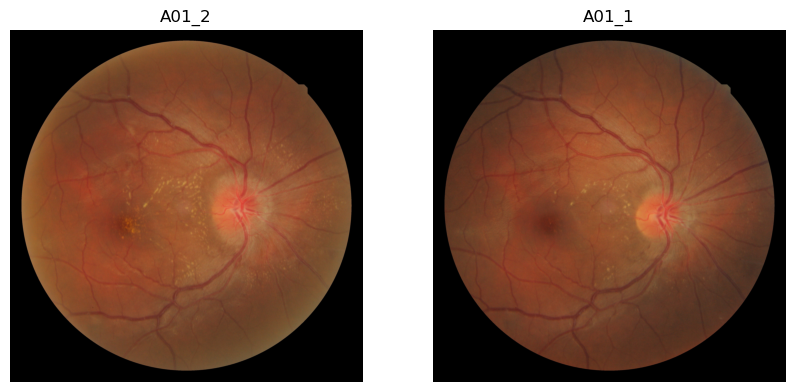

In [15]:
import matplotlib.pyplot as plt
import numpy as np
iter_dataloader = iter(dataloader)
first_batch = next(iter_dataloader)
second_batch = next(iter_dataloader)
third_batch = next(iter_dataloader)
img_ref, img_test, test_image_name, reference_image_name = first_batch



def show_image(test_image : torch.Tensor,
               reference_image: torch.Tensor,
               test_image_name: str = '',
               reference_image_name: str = ''
               )->None:
    #reference_image, test_image, test_image_name, reference_image_name = batch in case to use the dataloader itself
    reference_image_name, test_image_name = str(reference_image_name[0]), str(test_image_name[0])
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(test_image.squeeze().permute(1,2,0).numpy())
    ax[0].set_title(f'{test_image_name}')
    ax[0].axis('off')
    ax[1].imshow(reference_image.squeeze().permute(1,2,0).numpy())
    ax[1].set_title(f'{reference_image_name}')
    ax[1].axis('off')
    plt.show()

show_image(test_image=img_test, reference_image=img_ref, test_image_name=test_image_name, reference_image_name=reference_image_name)

    

In [16]:
type(img_ref)

torch.Tensor

### CUSTOM DATALOADER

In [17]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from typing import Tuple, Dict, List
import torch
import random
import os
from pathlib import Path

class ImageRegistrationCustom(Dataset):
    def __init__(self,
                dataset_folder_path: Path, # the path of FIRE dataset: Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE'
                transform=None, 
                target_transform=None)->None:
        self.dataset_path = dataset_folder_path
        path_to_image_types = dataset_folder_path / 'Images' 
        path_to_deformation_types = dataset_folder_path /  'Images' / 'Test' 
        self.reference_images_paths = list(dataset_folder_path.glob('Images/Reference/*/*.jpg'))
        self.test_images_paths = list(dataset_folder_path.glob('Images/Test/*/*.jpg'))
        self.transform = transform # da trasformare le singole immagini? 
        self.target_transform = target_transform
        self.image_types = [d.name for d in path_to_image_types.iterdir() if d.is_dir()]
        self.deformation_types = [d.name  for d in path_to_deformation_types.iterdir() if d.is_dir()]

    # costruisci un dict  per abbreviare long... super res e mosaicing in A, S, P ... ?
    def load_image(self, 
                   index : str | int = 'random', # valuta la possibilità di mettere il random in una funzione a parte
                   deformation: str= '') ->Image.Image: # given an index it get an image
        ''' 
        depending the type there are different possibilities
        depending which type f deformation to visualize
        ****aggiungi la possibilità di usare una trasformazione su un'immagine di test 
        '''
        images = list(self.dataset_path.glob('*/*/*/*'))
        
        if deformation == '':
            images = list(self.dataset_path.glob('*/*/*/*'))
        else:
            if deformation not in self.deformation_types:
                print(f'to see possibile selection use the method .deformation_types')
                raise ValueError(f"Deformation type {deformation} not found in the dataset")
            else:
                images = list(self.dataset_path.glob(f'*/*/*/{deformation}/*'))
        
        if index.lower() == 'random' or not isinstance(index, int):
            idx = random.randint(0, len(images)-1)
        elif isinstance(index, int):
            idx=index
            if index not in range(0, len(images)):
                print(f'[WARNING] - unable to get the {index} image, another one casually get from the dirs')
                idx = random.randint(0, len(images) - 1)
                images = list(self.dataset_path.glob('*/*/*/*')) 
        
        return Image.open(images[idx])      # aggiusta in una tupla 
        

    def __len__(self,
                info : bool = True):
        '''show the distribution of sample in the dataset path
        then the number of total files in the deepest folder'''
        if info:
            for dirpath, dirnames, filenames in os.walk(self.dataset_path):
                print(f"[INFO] - There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
        return len(list(self.dataset_path.glob('*/*/*/*')))
    
    def get_coupled_imgs(self,
                    index: bool|int = False,
                    deformation_choice : str = '' 
                    ) -> Tuple[torch.Tensor, torch.Tensor, str]:
        '''get the image pairs from the list of avaiable '''
        if deformation_choice == '' or deformation_choice not in self.deformation_types:
            test_images = list(self.dataset_path.glob('*/Test/*/*'))
            reference_images = list(self.dataset_path.glob('*/Reference/*/*'))
            print('[WARNING] - not a valid choice of deformation, the entire dataset is used as a batch') 
        else: 
            test_images = list(self.dataset_path.glob(f'*/*/Test/{deformation_choice}/*'))
            reference_images = list(self.dataset_path.glob(f'Images/Reference/{deformation_choice}/*.jpg'))
        if not index or index not in range(0, len(test_images)):
            index = random.randint(0, len(test_images)-1)
            
        test_image = test_images[index]
        reference_image = reference_images[index]
        test_reference,deformation, filename = get_dirs_of(test_image)
        print(f'the selected/chosen image is {filename}, from {deformation} folder of {test_reference}')
        if self.transform:
            reference_image = self.transform(Image.open(reference_image))  
        if self.target_transform:
            test_image = self.target_transform(Image.open(test_image))
        return test_image, reference_image, deformation

    def __getitem__(self, 
                    index : bool|int = False,
                    deformation_choice: str = ''):
        ''' get the images couple of reference/test as tensor tuple'''
        test_image, reference_image, _ = self.get_coupled_imgs(index=index, deformation_choice=deformation_choice)
        if self.transform:
            test_image = self.transform(test_image)
        if self.target_transform:
            reference_image = self.target_transform(reference_image)
        return test_image, reference_image 
            
        

In [18]:
fire_dataset_path = Path.cwd().parent / 'Modules' /'dataset'/'FIRE'

imreg_dataset = ImageRegistrationCustom(dataset_folder_path=fire_dataset_path)
img= imreg_dataset.load_image(deformation='', index='random')

test_img, reference_img, deformation = imreg_dataset.get_coupled_imgs()

print(f'the shape of the image *test_img* open with Image.open(Path): {np.asarray(Image.open(test_img)).shape}, type {type(Image.open(test_img))}\n just befor numpy conversion')
print(f'the shape of the image *img_test* open with the DAtaloader as a tensor: {img_test.shape}, type {type(img_test)}')

[WARNING] - not a valid choice of deformation, the entire dataset is used as a batch
the selected/chosen image is S26_2.jpg, from Super_Resolution folder of Test
the shape of the image *test_img* open with Image.open(Path): (2912, 2912, 3), type <class 'PIL.JpegImagePlugin.JpegImageFile'>
 just befor numpy conversion
the shape of the image *img_test* open with the DAtaloader as a tensor: torch.Size([1, 3, 2912, 2912]), type <class 'torch.Tensor'>


### DATALOADER + PYRAMID 
get the dataloader from simply dataloader and add pyramid transformation after transforms...

In [19]:
# create a new dataloader to get the pyramid of images just after retreriving the image from dataset, 
# let the image registration function just out to use it out of the training loop


## Preprocess the image from the dataloader for the nn

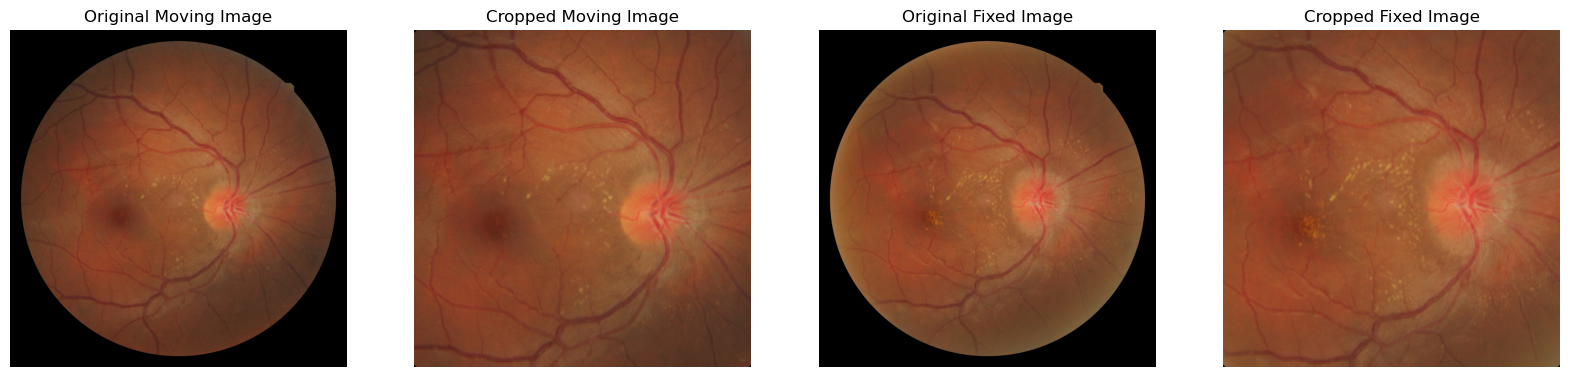

In [20]:
def crop_images(moving_image : Path | torch.Tensor,
                fixed_image : Path | torch.Tensor,
                show_images : bool = False
                )-> Tuple[torch.Tensor, torch.Tensor]:
    '''
    given the images it crop to the desired size 
    if requested the images are shown as confront between the original and the cropped
    
    Parameters:
    moving_image : Path | torch.Tensor
        the image to crop, it can be a path or a tensor given by the dataloader
    fixed_image : Path | torch.Tensor
        the image to crop, it can be a path or a tensor given by the dataloader 
    show_images : bool
        whether to show the images or not
        
    Returns:
        Tuple[torch.Tensor, torch.Tensor]: the cropped images
        
    '''

    #open the images depending on the type
    if isinstance(moving_image, Path):
        if not moving_image.exists():
            raise FileNotFoundError(f'{moving_image} not found')
        else:
            move_image = np.asarray(Image.open(moving_image))
    if isinstance(fixed_image, Path):
        if not fixed_image.exists():
            raise FileNotFoundError(f'{fixed_image} not found')
        else:
            fix_image = np.asarray(Image.open(fixed_image))
    
    if isinstance(moving_image, torch.Tensor):
        move_image = moving_image.squeeze().permute(1,2,0).numpy()
    if isinstance(fixed_image, torch.Tensor):
        fix_image = fixed_image.squeeze().permute(1,2,0).numpy()
    
    cropped_moving_image = move_image[int(move_image.shape[0]*LOWEDGE_BOX):int(move_image.shape[0]*HIGHEDGE_BOX), int(LOWEDGE_BOX*move_image.shape[1]):int(HIGHEDGE_BOX*move_image.shape[1]), :]
    cropped_fixed_image = fix_image[int(LOWEDGE_BOX*fix_image.shape[0]):int(fix_image.shape[0]*HIGHEDGE_BOX), int(LOWEDGE_BOX*fix_image.shape[1]):int(HIGHEDGE_BOX*fix_image.shape[1]), :]


    if show_images:
        # show the images
        fig, ax = plt.subplots(1, 4, figsize=(20, 5))
        ax[0].imshow(move_image)
        ax[0].set_title('Original Moving Image')
        ax[0].axis('off')
        ax[1].imshow(cropped_moving_image)
        ax[1].set_title('Cropped Moving Image')
        ax[1].axis('off')
        ax[2].imshow(fix_image)
        ax[2].set_title('Original Fixed Image')
        ax[2].axis('off')
        ax[3].imshow(cropped_fixed_image)
        ax[3].set_title('Cropped Fixed Image')
        ax[3].axis('off')
        plt.show()
    batched_moving = torch.from_numpy(cropped_moving_image).permute(2,0,1).unsqueeze(0)
    batched_fixed = torch.from_numpy(cropped_fixed_image).permute(2,0,1).unsqueeze(0)
    return batched_moving, batched_fixed

moved_image,fixed_image = crop_images(moving_image=img_ref, fixed_image=img_test, show_images=True)
    


In [21]:
img_ref.shape

torch.Size([1, 3, 2912, 2912])

In [22]:
# given the two tensor with shape of [1, 3, 1941, 1941]
# get the pyramid of images from skimage.transform.pyramid_gaussian
from skimage.transform import pyramid_gaussian
from skimage.filters import gaussian
def coupled_gaussian_pyramid(fixed_image : np.float32 | torch.Tensor,
                             moving_image : np.float32 | torch.Tensor,
                             downscale : float = 2.0,
                             )-> (list[np.float32], list[np.float32], int):
    '''
    it takes two images to performa gaussian filter in 6 progressive steps
    Parameter
    ---------
    fixed_image : np.float32
      the fixed image

    moving_image : np.float32
      the moving image

    downscale : float
      the downscale factor to decide the factor of downsampling in each subsequent step

    Returns
    -------
    (list[np.float32], list[np.float32])
      the gaussian pyramid of the two images
    nChannel : int
      the number of channels of the image

    '''   
    if np.ndim(fixed_image) != np.ndim(moving_image) or type(fixed_image) != type(moving_image):
      raise ValueError("the two images must have the same type and dimension")
    else:
        if isinstance(fixed_image, torch.Tensor):
            fixed_image = fixed_image.squeeze().permute(1,2,0).numpy()
            moving_image = moving_image.squeeze().permute(1,2,0).numpy()
        if np.ndim(fixed_image) == 3:
            nChannel=fixed_image.shape[2]
            pyramid_fixed = tuple(pyramid_gaussian(gaussian(fixed_image, sigma=1, channel_axis=-1), downscale=downscale, channel_axis=-1))
            pyramid_moving = tuple(pyramid_gaussian(gaussian(moving_image, sigma=1, channel_axis=-1), downscale=downscale, channel_axis=-1))
        elif np.ndim(fixed_image) == 2:
            nChannel=1
            pyramid_fixed = tuple(pyramid_gaussian(gaussian(fixed_image, sigma=1, channel_axis=None), downscale=downscale))
            pyramid_moving = tuple(pyramid_gaussian(gaussian(moving_image, sigma=1, channel_axis=None), downscale=downscale))
        else:
            print(f"Unknown rank for an image: {np.ndim(fixed_image)}")

    return (pyramid_fixed, pyramid_moving, nChannel)
pyramid_ref, pyramid_mov, nChannel = coupled_gaussian_pyramid(fixed_image=fixed_image, moving_image=moved_image, downscale=2.0)


## CREATE THE NN 

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from skimage.filters import sobel
from skimage.color import rgb2gray
from torch.autograd import Function
import cv2 
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [25]:
class HomographyNet(nn.Module):
    def __init__(self):
        super(HomographyNet, self).__init__()
        # affine transform basis matrices

        self.B = torch.zeros(6,3,3).to(device)
        self.B[0,0,2] = 1.0
        self.B[1,1,2] = 1.0
        self.B[2,0,1] = 1.0 
        self.B[3,1,0] = 1.0 
        self.B[4,0,0], self.B[4,1,1] = 1.0, -1.0
        self.B[5,1,1], self.B[5,2,2] = -1.0, 1.0

        #inizializzatione  parametri
        self.v1 = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)
        self.vL = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)

    def forward(self, s):
        C = torch.sum(self.B*self.vL,0)
        if s==0: # caso in cui ci si trovi nel primo livello
            C += torch.sum(self.B*self.v1,0)
        A = torch.eye(3).to(device)
        H = A
        for i in torch.arange(1,10):
            A = torch.mm(A/i,C)
            H = H + A
        return H
Homography_net = HomographyNet()

In [26]:
n_neurons = 100
class MINE(nn.Module): #https://arxiv.org/abs/1801.04062
    def __init__(self, nChannel: int):
        super(MINE, self).__init__()
        self.nChannel = nChannel
        self.fc1 = nn.Linear(2*self.nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient
        

    def forward(self, x, ind):
        x = x.view(x.size()[0]*x.size()[1],x.size()[2])
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))]
            z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:self.nChannel],x[ind_perm,self.nChannel:2*self.nChannel]),1))))))
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize, z1, z2

In [27]:
def AffineTransform(I, H, xv, yv):
    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze()
    return J



def multi_resolution_loss(I_lst : list[torch.Tensor],
                          J_lst : list[torch.Tensor],
                          xy_lst : list[torch.Tensor],
                          ind_lst : list[torch.Tensor],
                          homography_net : HomographyNet,
                          mine_net : MINE,
                          L : int = 6,
                          
                          nChannel : int = 3,
                          
                          ):
    loss=0.0
    z1, z2 = [], [] # NOTE use z1 z2 to track the loss doing on MINE net
    for s in np.arange(L-1,-1,-1):
      if nChannel>1:
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.cat([I_lst[s],Jw_],0).permute(1,2,0),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
      else:
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0).unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.stack([I_lst[s],Jw_],2),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
    
    return loss, z1, z2

# mattes mutual information ( MMI)
def histogram_mutual_information(image1, image2):
    hgram, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hgram / float(np.sum(hgram))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))




In [28]:
import cv2
def images_registration(pyramid_fixed: tuple[np.ndarray],
                        pyramid_moving: tuple[np.ndarray],
                        L: int =6,
                        sampling: float = 0.1,
                        nChannel : int = 3,
                        ) -> tuple[list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor],list[torch.Tensor], list[int], list[int]]:
  '''
  it registers the images calculating the random index for the homography to compare the registration and optimize the corresponding value xy_
  it also prepare the pyramidal images permuting the index position as (H,W,C) -> (C, H, W)

  Parameters
  ------------
  pyramid_fixed : tuple[numpy.ndarray]
    the pyramid of multiresolution from the fixed image
  pyramid_moving : tuple[numpy.ndarray]
    the pyramid of multiresolution from the moving image
  L : int
    the coarsest resolution level
  sampling : float
    the percentage of sampling to be used in homography optimization
  seed : int
    since the sampling is random the seed is useful for reproducibility

  Returns
  -------
  I_lst: list[torch.Tensor]
    the image pyramid of the fixed image listed as torch tensor of normalized value as np.float32
  J_lst: list[torch.Tensor]
    the image pyramid of the moving image listed as torch tensor of normalized value as np.float32
  x_ : list[torch.Tensor]
   the x coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  y_ : list[torch.Tensor]
    the y coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  xy_ : list[torch.Tensor]
    the coordinates for the homography mapping
  ind_ : list[torch.Tensor]
    the random index for the homography optimization
  h_ : list[int]
    the heights of images in pyramid, necessary due downsampling
  w_ :  list[int]
    the widths of images in pyramid, necessary due downsampling
  '''
  if sampling > 1.0:
    raise ValueError("sampling must be between 0 and 1")


  I_lst,J_lst,h_lst,w_lst,xy_lst,ind_lst=[],[],[],[],[],[]
  pyramid_I = pyramid_fixed
  pyramid_J = pyramid_moving

  for s in range(L):
    I_ = torch.tensor(cv2.normalize(pyramid_I[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device)   # -------param pyramid_i , pyramif_j
    J_ = torch.tensor(cv2.normalize(pyramid_J[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device) # normalization for normalized coordinates

    if nChannel>1:
        I_lst.append(I_.permute(2,0,1)) # permute (H,W, C) -> (C, H, W)
        J_lst.append(J_.permute(2,0,1))
        h_, w_ = I_lst[s].shape[1], I_lst[s].shape[2]
        ind_ = torch.randperm(int(h_*w_*sampling)) # rand perm
        ind_lst.append(ind_)
    else:
        I_lst.append(I_)
        J_lst.append(J_)
        h_, w_ = I_lst[s].shape[0], I_lst[s].shape[1]
        ind_ = torch.randperm(int(h_*w_*sampling))
        ind_lst.append(ind_)
    h_lst.append(h_)
    w_lst.append(w_)

    y_, x_ = torch.meshgrid([torch.arange(0,h_).float().to(device), torch.arange(0,w_).float().to(device)], indexing='ij')
    y_, x_ = 2.0*y_/(h_-1) - 1.0, 2.0*x_/(w_-1) - 1.0 # normalization -1.0 ->  1.0
    xy_ = torch.stack([x_,y_],2)
    xy_lst.append(xy_)
  return (I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst)
I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)


In [29]:
def normalize(tens_image : torch.Tensor
              )-> torch.Tensor:
    '''
    get a tensor to normalize it throught the scaler'''
    maxim = np.max(tens_image.numpy())
    minim = np.min(tens_image.numpy())

    if maxim == minim:
        return torch.zeros_like(tens_image)
    
    return (tens_image -minim)/ (maxim - minim)
    

#### reproduce the net work for a single image resolution

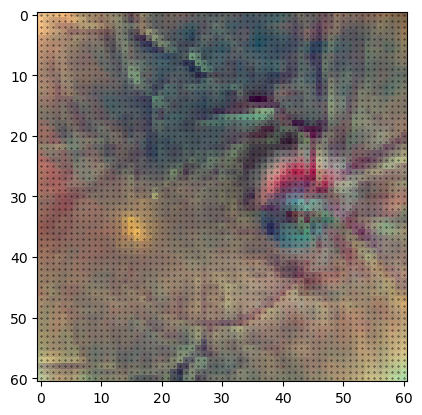

In [30]:
I5_norm = normalize(I_lst[5])
J5_norm = normalize(J_lst[5])

y5 = y_[5]
xy5 = xy_lst[5].numpy()
ind5 = ind_lst[5]
h5 = h_lst[5]
w5 = w_lst[5]

x5, y5 = torch.meshgrid([torch.arange(0,h5).float(), torch.arange(0,w5).float()], indexing='ij')
xy5 = torch.stack([x5,y5],2)

x_coords = xy5[..., 0].flatten()
y_coords = xy5[..., 1].flatten()
diff5 = (I5_norm - J5_norm)
diff5_norm = normalize(diff5)
plt.imshow(diff5_norm.permute(1,2,0).numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.1)



In [31]:
xy5[:10,:10,:].numel()

200

In [32]:

n_neurons = N_NEURONS
class MINE_INSIDE(nn.Module):
    def __init__(self, nChannel: int):
        super(MINE_INSIDE, self).__init__()
        self.fc1 = nn.Linear(2*nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient

    def forward(self, y, ind):
        x = y.view(y.size()[0]*y.size()[1],y.size()[2]) #flatten the tensor to use the rand perm and get random index
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))] # perchè non provare a farlo qua dentro usando torch.randperm(int(len(x[0]*sampling)))
            z1_first = F.relu(self.fc1(x[ind,:]))
            z2_first = self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))
            z1_second = F.relu(self.fc2(z1_first)) 
            z2_second = self.fc2(z2_first)
            z1 = self.fc3(z1_second) 
            z2 = self.fc3(z2_second)
            #z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            #z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))))))
            print(f'''x[ind,0:nChannel] shape : {x[ind,0:nChannel].shape},
                x[ind_perm,nChannel:2*nChannel]shape : {x[ind_perm,nChannel:2*nChannel].shape},
                the input_shape is : {x[ind,:].shape},
                after the first layer the output shape is : {z2_first.shape},
                after the second layer the output shape is : {z1_second.shape},
                the third layer shape : {z2.shape}.
                The original tensor is x: {y.shape}, after the forward pass the shae change into: {x.shape}
                ''')
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize


In [33]:
homography_net = HomographyNet()
Jw5 = AffineTransform(J_lst[5].unsqueeze(0), homography_net(5), xy5[:,:, 0], xy5[:,:, 1]).squeeze()
x =torch.cat([I_lst[5], Jw5], 0).permute(1,2,0)
ind =ind5
mine_net = MINE_INSIDE(nChannel=3)
mi = mine_net(x, ind)
x_new = x.view(x.size()[0]*x.size()[1],x.size()[2])
x_new.shape

x[ind,0:nChannel] shape : torch.Size([372, 3]),
                x[ind_perm,nChannel:2*nChannel]shape : torch.Size([372, 3]),
                the input_shape is : torch.Size([372, 6]),
                after the first layer the output shape is : torch.Size([372, 100]),
                after the second layer the output shape is : torch.Size([372, 100]),
                the third layer shape : torch.Size([372, 1]).
                The original tensor is x: torch.Size([61, 61, 6]), after the forward pass the shae change into: torch.Size([3721, 6])
                


torch.Size([3721, 6])

In [34]:
import torchinfo
minet = MINE(nChannel=3)
s=3
I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)
Jws = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:, 0], xy_lst[s][:,:, 1]).squeeze()
x =torch.cat([I_lst[s], Jws], 0).permute(1,2,0)
ind =ind_lst[s]
S_summary = torchinfo.summary(minet, input_data=(x, ind))


In [35]:
S_summary

Layer (type:depth-idx)                   Output Shape              Param #
MINE                                     --                        --
├─Linear: 1-1                            [5904, 100]               700
├─Linear: 1-2                            [5904, 100]               10,100
├─Linear: 1-3                            [5904, 1]                 101
├─Linear: 1-4                            [5904, 100]               (recursive)
├─Linear: 1-5                            [5904, 100]               (recursive)
├─Linear: 1-6                            [5904, 1]                 (recursive)
Total params: 10,901
Trainable params: 10,901
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 128.72
Input size (MB): 1.46
Forward/backward pass size (MB): 18.99
Params size (MB): 0.04
Estimated Total Size (MB): 20.50

tensor([  0.,   0.,   0.,  ..., 485., 485., 485.])

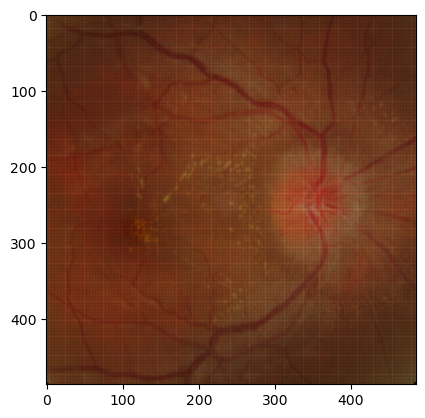

In [36]:
# create a function to visualize the meshgrid or x_, y_ xy_, h_list, w_list, ind_list on the image to see
# # the correspondence between the coordinates' values and the image
import matplotlib.pyplot as plt
import numpy as np

I3 = normalize(I_lst[2])
J3 = normalize(J_lst[2])

y3 = y_[3]
xy3 = xy_lst[2].numpy()
ind3 = ind_lst[2]
h3 = h_lst[2]
w3 = w_lst[2]
x3, y3 = torch.meshgrid([torch.arange(0,h3).float(), torch.arange(0,w3).float()], indexing='ij')
xy3 = torch.stack([x3,y3],2)

x_coords = xy3[..., 0].flatten()
y_coords = xy3[..., 1].flatten()
diff3 = (I3 - J3)
diff3_norm = normalize(diff3)
plt.imshow(I3.permute(1,2,0).numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.001)
x_coords


In [37]:
# rearrange the loss funciton parameter to take inn two objects, the image of the dataset and the predicted through the MINE net 
# per una coppia di immagini :
# train -> loss
# omografia -> loss ...

In [38]:
x = torch.Tensor(np.arange(0, 10 , 1))
y = torch.Tensor(np.arange(0, 20 , 1))
ij_mesh1, ij_mesh2 = torch.meshgrid(x, y, indexing='ij')
xy_mesh1, xy_mesh2 = torch.meshgrid(x, y, indexing='xy')
xy_mesh2, ij_mesh2

(tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
         [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
         [ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.],
         [ 4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.],
         [ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.],
         [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.],
         [ 7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.],
         [ 8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.],
         [ 9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.],
         [10., 10., 10., 10., 10., 10., 10., 10., 10., 10.],
         [11., 11., 11., 11., 11., 11., 11., 11., 11., 11.],
         [12., 12., 12., 12., 12., 12., 12., 12., 12., 12.],
         [13., 13., 13., 13., 13., 13., 13., 13., 13., 13.],
         [14., 14., 14., 14., 14., 14., 14., 14., 14., 14.],
         [15., 15., 15., 15., 15., 15., 15., 15., 15., 15.],
         [16., 16., 16.,

In [39]:
h = 4
w = h
image = torch.Tensor(np.random.randn(h, w, 3))

index = torch.randperm(int(h*w))


for i in range(len(ind_lst)):
    print(f'the {i}-th element has {len(ind_lst[i])} elements')

the 0-th element has 376748 elements
the 1-th element has 94284 elements
the 2-th element has 23619 elements
the 3-th element has 5904 elements
the 4-th element has 1488 elements
the 5-th element has 372 elements


## Functioning


In [40]:
# creare una funzione per visualizzare le immagini 
def show_images(im1,
                im2,
                ):
    pass

In [42]:
ground_path =  Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Ground Truth'
control_points = [n for n in list(ground_path.glob('*')) if n.name.__contains__('A01')]
control_points

[WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Modules/dataset/FIRE/Ground Truth/control_points_A01_1_2.txt')]

In [43]:
# prendere le coordinate dalla lista dei valori di riferimento

def get_coords(image_name : str, #es A01
               ground_truth_path : Path, # in this case: control_points_[Image pair name]_1_2.txt
               )-> tuple(list[float]):
    '''
    get the coordinates of control points associate to the image in list of coords format
    the format in the ground truth folder:
    [reference_point_1_x] [reference_point_1_y] [test_point_1_x] [test_point_1_y]
    [reference_point_2_x] [reference_point_2_y] [test_point_2_x] [test_point_2_y]

    it will returns the list of coords for both test(_2) and reference image(_1) 
    '''
    if not ground_truth_path.exists():
        raise FileNotFoundError(f'directory {ground_truth_path} not found')
    txt_file_path = [n for n in list(ground_truth_path.glob('*')) if n.name.__contains__(image_name)]
    reference_points, test_points = [], []
    with open(txt_file_path[0], 'r') as file:
        lines = file.readlines()
        for line in lines:
            ref_x, ref_y, test_x, test_y = line.split()
            reference_points.append([float(ref_x), float(ref_y)])
            test_points.append([float(test_x), float(test_y)])
    return test_points, reference_points


this_path = Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE' / 'Ground Truth' 

test_points, reference_points = get_coords(image_name='A01', ground_truth_path=this_path) # dato che la valutazione è sull'ultimo è questa quella che dovrebbe pesare di più sulla scala delle MI

In [44]:
reference_points

[[332.0, 872.0],
 [370.0, 1897.0],
 [1212.0, 2483.0],
 [1761.0, 348.0],
 [2384.0, 1912.0],
 [2527.0, 1099.0],
 [1922.0, 1131.0],
 [642.0, 1222.0],
 [1930.0, 1408.0],
 [1339.0, 1768.0]]

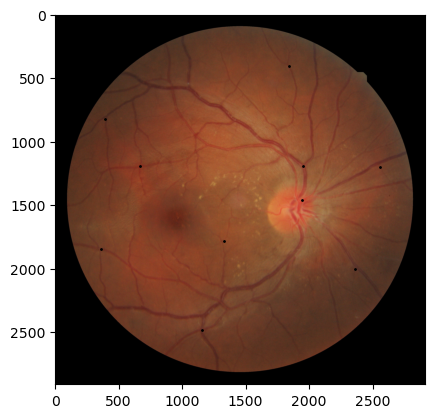

In [45]:
x_test = [test_point[0] for test_point in test_points]
y_test = [test_point[1] for test_point in test_points]
test_to_open = np.asarray(img_ref.squeeze().permute(1,2,0))
plt.scatter(x_test, y_test, c='black', s=1)
plt.imshow(test_to_open)

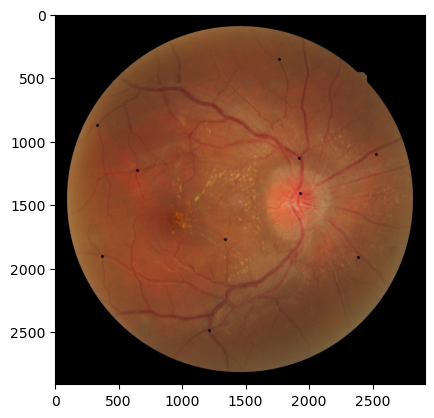

In [46]:
x_ref = [reference_point[0] for reference_point in reference_points]
y_ref = [reference_point[1] for reference_point in reference_points]
ref_to_open = np.asarray(img_test.squeeze().permute(1,2,0))
plt.scatter(x_ref, y_ref, c='black', s=1)
plt.imshow(ref_to_open)

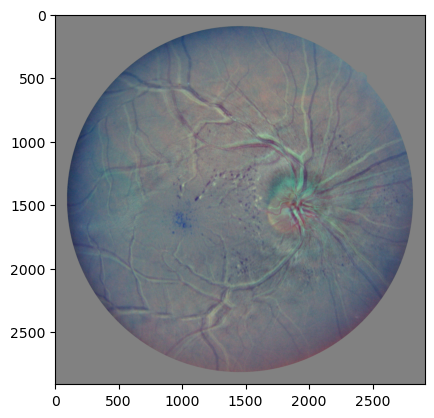

In [47]:
im_ref = normalize(img_ref.squeeze().permute(1,2,0))
im_test = normalize(img_test.squeeze().permute(1,2,0))
im = normalize(im_ref - im_test)
plt.imshow(im)


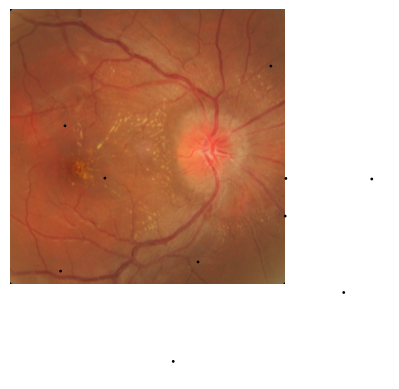

In [48]:
s = 0
Is = normalize(I_lst[s])
Js = normalize(J_lst[s])

ys = y_[s]
xys = xy_lst[s].numpy()
inds = ind_lst[s]
hs = h_lst[s]
ws = w_lst[s]
xs, ys = torch.meshgrid([torch.arange(0,hs).float(), torch.arange(0,ws).float()], indexing='ij')
xys = torch.stack([xs,ys],2)

x_coords = xys[..., 0].flatten()
y_coords = xys[..., 1].flatten()
x_test = [test_point[0] for test_point in test_points]
y_test = [test_point[1] for test_point in test_points]

diffs = (Is - Js)
diffs_norm = normalize(diffs)
# creare una funzione per visualizzare i punti di riferimento e le corrispondenze tra i punti di riferimento e le immagini
def show_image_and_reference_points(s: int, 
                                    coordinates: list[list[float]],
                                    title : str = get_data_time(),
                                    uniform_color : bool = True,
                                    image: torch.Tensor = Is,):
    x_test = [test_point[0] for test_point in coordinates]
    y_test = [test_point[1] for test_point in coordinates]
    result_image_folder = Path.cwd().parent / 'Results' /'ImgRes'
    plt.imshow(image.permute(1,2,0).numpy())
    plt.axis('off')
    if not uniform_color:
        colors = plt.cm.jet(np.linspace(0, 1, len(coordinates)))
    else: 
        colors = ['black'] * len(coordinates)
    '''for i, (x, y) in enumerate(coordinates):
        plt.scatter(x, y, c=colors[i], s=1)'''
    plt.scatter(x_test, y_test, c=colors, s=1)
    plt.savefig(result_image_folder / f'{title}.png')


show_image_and_reference_points(s=0, coordinates=test_points)


In [49]:
#non tutti i punti sono papabili, pertanto bisogna tolgiere quelli che sono out of the box: (1.5/9. - 7.5/9) * shape image
xshape, yshape = ORIGINAL_SHAPE
test_points, reference_points
def remove_coord_outside_box(coords : list[list[float]],
                            original_shape : tuple[int] = ORIGINAL_SHAPE,
                            upper_edge: float = 7.5/9.,
                            lower_edge: float = 1.5/9.,
                            )-> list[list[float]]:
    '''
    remove the coordinates that are outside the box of the image
    '''
    xshape, yshape = original_shape
    print(f'xshape: {xshape}, yshape: {yshape}')
    modified_coords = []
    xlimit, ylimit = int(xshape*upper_edge), int(yshape*upper_edge)
    xbase, ybase = int(xshape*lower_edge), int(yshape*lower_edge)
    
    for coord in coords:
        x_coord , y_coord = coord
        if x_coord not in range(xbase, xlimit +1):
            print(f'since {x_coord} is outside the box, {x_coord, y_coord} will be removed') # logging
            continue
        elif y_coord not in range(ybase, ylimit +1):
            print(f'since {y_coord} is outside the box, {x_coord, y_coord} will be removed') #logging
            continue
        else:
            x_coord -= xbase
            y_coord -= ybase
            print(f'the new coord are {x_coord}, {y_coord}')#logging
            coord = (x_coord, y_coord)
            modified_coords.append(coord)

    return modified_coords


# if just one of the value in the coords is outside the box of the image, it should be removed
# then remove from both x and y coords the min value of  1.5/9.*shape[0] to reassest the coords in the visualization
# remember to pack two tuple of coords in the list to get the evaluation, just after the crop and before it.

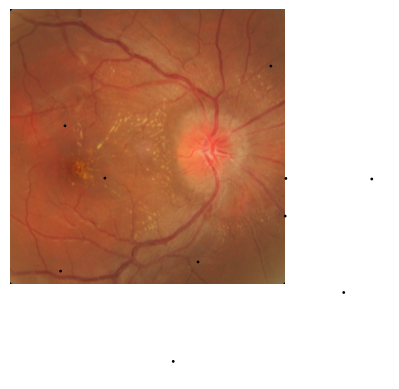

In [50]:
show_image_and_reference_points(s=0, coordinates=test_points, title='Is_and_test_points')

xshape: 2912, yshape: 2912
since 388.0 is outside the box, (388.0, 822.0) will be removed
since 357.0 is outside the box, (357.0, 1849.0) will be removed
since 2487.0 is outside the box, (1153.0, 2487.0) will be removed
since 400.0 is outside the box, (1843.0, 400.0) will be removed
the new coord are 1873.0, 1515.0
since 2556.0 is outside the box, (2556.0, 1198.0) will be removed
the new coord are 1464.0, 709.0
the new coord are 185.0, 707.0
the new coord are 1459.0, 975.0
the new coord are 843.0, 1299.0
xshape: 2912, yshape: 2912
since 332.0 is outside the box, (332.0, 872.0) will be removed
since 370.0 is outside the box, (370.0, 1897.0) will be removed
since 2483.0 is outside the box, (1212.0, 2483.0) will be removed
since 348.0 is outside the box, (1761.0, 348.0) will be removed
the new coord are 1899.0, 1427.0
since 2527.0 is outside the box, (2527.0, 1099.0) will be removed
the new coord are 1437.0, 646.0
the new coord are 157.0, 737.0
the new coord are 1445.0, 923.0
the new coor

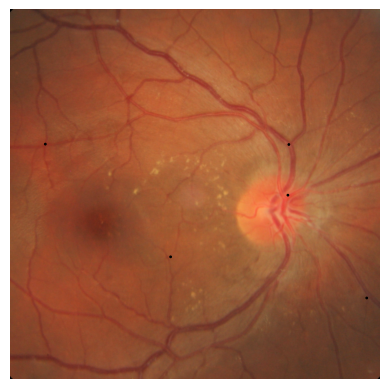

In [51]:
cropped_test_points = remove_coord_outside_box(test_points)
cropped_reference_points = remove_coord_outside_box(reference_points)
show_image_and_reference_points(s=0, coordinates=cropped_test_points, image=Js, title='Js_and_cropped_test_points')

In [52]:
Js.shape

torch.Size([3, 1941, 1941])

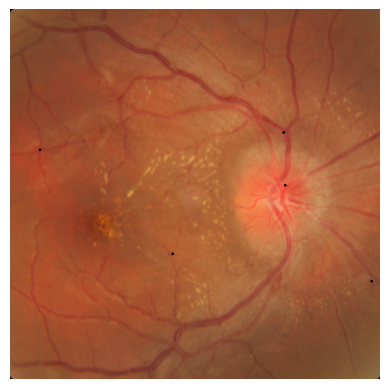

In [53]:
show_image_and_reference_points(s=0, coordinates=cropped_reference_points, title='Is_and_reference_points') # Is and reference points

In [54]:
img_ref.numel() == img_test.numel()

True

In [55]:
def AffineTransform(I, H, xv, yv):
    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze()
    return J # it's torch.Tensor type
xv = torch.Tensor([x[0] for x in cropped_test_points])
yv = torch.Tensor([x[1] for x in cropped_test_points])
homography_net = HomographyNet()
homo_matrix = homography_net(0)


In [56]:
loss_vals = []
for s in np.arange(5, -1, -1):
    Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
    print(f'Jw_ shape is {Jw_.shape}')
    loss_val = torch.cat([I_lst[s], Jw_], 0)
    loss_vals.append(loss_val)



Jw_ shape is torch.Size([3, 61, 61])
Jw_ shape is torch.Size([3, 122, 122])
Jw_ shape is torch.Size([3, 243, 243])
Jw_ shape is torch.Size([3, 486, 486])
Jw_ shape is torch.Size([3, 971, 971])
Jw_ shape is torch.Size([3, 1941, 1941])


In [58]:
# creare una funzione per trovare le nuove coordinate dei punti di riferimento dopo l'omografia e visualizzarli

def transform_points(points, H):
    # Convert points to homogeneous coordinates
    ones = torch.ones(points.shape[0], 1)
    homogeneous_points = torch.cat([points, ones], dim=1)
    
    # Apply homography
    transformed_points = torch.matmul(homogeneous_points, H.T)
    
    # Convert back to Cartesian coordinates
    transformed_points = transformed_points[:, :2] / transformed_points[:, 2].unsqueeze(1)
    transformed_points_int_list = [[int(round(x)), int(round(y))] for x, y in transformed_points.tolist()]
    
    return transformed_points_int_list

# Esempio di utilizzo
points =cropped_reference_points
transformed_points = transform_points(torch.Tensor(points), homo_matrix)
transformed_points,cropped_reference_points # verificato che siano uguali

([[1899, 1427], [1437, 646], [157, 737], [1445, 923], [854, 1283]],
 [(1899.0, 1427.0),
  (1437.0, 646.0),
  (157.0, 737.0),
  (1445.0, 923.0),
  (854.0, 1283.0)])

In [ ]:
# creare una funzione per la loss e valutarla in merito a tali punti
def loss_reference_points(reference_list : list[[int, int]], # for I image
                          homography_matrix : torch.Tensor,
                          test_list : list[[int, int]], # for J image
                          ) -> float :
    ''' given two list of coordinates, it get the euclidean distance between these two:
    calculated as the difference between the test point and the affine transformation of the coordinate through the homography tensor
    Args:
        reference_list (list[[int, int]]): list of coordinate points of the image of reference
        test_list (list[[int, int]]): list of coordinate points of the image to test the homography on
        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss 
    '''
    if len(reference_list) != len(test_list):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.0
        test_coords = transform_points(torch.Tensor(test_list), homography_matrix)
        for i in range(len(reference_list)):
            x_ref, y_ref = reference_list[i]
            x_test, y_test = test_coords[i]
            loss += np.sqrt((x_ref - x_test)**2 + (y_ref - y_test)**2)
        return loss

# creare una funzione per la loss e valutarla in merito al valore in tali punti
def loss_value_points(reference_points : list[[int, int]],  # for the  I image
                          test_points : list[[int, int]], # for the J image
                          reference_image : torch.Tensor, # for the I image
                          warped_image : torch.Tensor, # for the Jimage
                          homography_matrix : torch.Tensor,
                          ) -> float :
    ''' 
    given two list of coordinates(reference_points), 
    it get the differences in values between the test image and the warped one in these coordinates

    Assume that all the images both the fixed and the warped one are both of same shape and resulted from the dataloader,
    ready to be processed by the net of shape [3, N ,N] or [N ,N]

    Args:
        reference_points (list[[int, int]]): list of coordinate points of the image of reference I

        test_points (list[[int, int]]): list of coordinate points of the image to test the homography on J

        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss H

        reference_image the image of reference I

        warped_image the image to be tested J
    '''
    if len(reference_points) != len(test_points):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.
        test_coords = transform_points(torch.Tensor(test_points), homography_matrix)

        for i in range(len(reference_points)):
            x_ref, y_ref = reference_points[i] 
            x_test, y_test = test_coords[i]
            if np.min(reference_image.shape) == 3: # nChannel==3
                reference_value = torch.sum(reference_image[:, x_ref, y_ref]).item()
                warped_value = torch.sum(warped_image[:, x_test, y_test]).item()

            else:
                reference_value = reference_image[x_ref, y_ref].item()
                warped_value = warped_image[x_test, y_test].item()
            loss += np.abs(reference_value - warped_value)
        return loss

def loss_value_images(I : torch.Tensor,
                      J : torch.Tensor,
                      shape_independece : bool = True,
                      )-> float:
    ''' get the loss value between two images'''
    if I.shape != J.shape:
        raise ValueError("the two images must have the same shape")
    else:
        if np.min(I.shape) == 1:
            I = I.squeeze()
            J = J.squeeze()
        I_norm = normalize(I)
        J_norm = normalize(J)
        if shape_independece:
            shape_normalizator = I.shape[0] * I.shape[1]
            return torch.abs(I_norm - J_norm).sum()/shape_normalizator
        else:
            return torch.abs(I_norm - J_norm).sum()

def mse_loss(img_fixed: np.ndarray | torch.Tensor,
             img_moving: np.ndarray |torch.Tensor,
             )-> float:
    ''' get the mean squared error loss between two images
    
    Parameter:
    img_fixed (np.ndarray | torch.Tensor): the fixed image
    img_moving (np.ndarray | torch.Tensor): the moving image
    
    Returns:
    float: the mean squared error loss between the two images, normalized over their size
    '''

    if img_fixed.shape != img_moving.shape:
        raise ValueError("the two images must have the same shape")
    if type(img_fixed) != type(img_moving):
        raise TypeError("the two images must have the same type")
    elif isinstance(img_fixed, torch.Tensor):
        img_fixed = img_fixed.squeeze().permute(1,2,0).numpy()
        img_moving = img_moving.squeeze().permute(1,2,0).numpy()


    return np.sum((img_fixed - img_moving)**2)/img_fixed.size

def mutual_information_loss(fixed_image: np.ndarray | torch.Tensor,
                            warped_image : np.ndarray | torch.Tensor,
                            index_list: torch.Tensor,
                            mine_net : MINE,
)-> float :
    '''
    the loss calculate through the mutual information between the two pyramids
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        the fixed image as reference or ground truth
    warped_image : np.ndarray | torch.Tensor
        the warped image as the input
    index_list : list[torch.Tensor]
        the index list to be used to calculate the mutual informationLoss 
    mien_net : MINE 
        the MINE network to be used to calculate the mutual informationLoss
    '''
    mi_loss = 0.0
    if fixed_image.shape != warped_image.shape:
        raise ValueError("the two images must have the same shape")
    if type(fixed_image) != type(warped_image):
        raise TypeError("the two images must have the same type")
    elif isinstance(fixed_image, np.ndarray):
        fixed_image = torch.from_numpy(fixed_image)
        warped_image = torch.from_numpy(warped_image)
    if fixed_image.ndim == 2:
        mi_loss = mine_net(torch.stack([fixed_image, warped_image], 2), index_list)
    else:
        mi_loss = mine_net(torch.cat([fixed_image, warped_image], 0).permute(1,2,0), index_list)
    return mi_loss      

def pyramid_mi_loss(fixed_pyramid : list[torch.Tensor],
                    warped_pyramid : list[torch.Tensor],
                    index_list :list,
                    mine_net : MINE,
                    ) -> float :
    '''
    the function perform the mutual loss calculation over the pyramid of images

    Parameters :
        fixed_pyramid : list of different resolution images for references

        warped_pyramid : list of different resolution images for warped images

        index_list : list of indices for the homography transformation, indicate the coordinates of points in image pairs

        mine_net the network to calculate the mi_loss 

    Returns :
        the mutual information loss between the two pyramids of images
            '''     
    if len(fixed_pyramid) != len(warped_pyramid) != len(index_list):
        raise ValueError("the two pyramids and the index list must have the same length ")   
    mi_loss = 0.0
    L = len(fixed_pyramid)
    for s in np.arange(L-1, -1, -1):
        mi_loss -= mutual_information_loss(fixed_image=fixed_pyramid[s], warped_image=warped_pyramid[s], index_list=index_list[s], mine_net=mine_net)/L

    return mi_loss

### DA FARE : RIFORMULA LE LOSS CONSIDERANDOLE COME DELLE NETWORK IN MODO CHE I PESI DELLE RETI VENGANO AGGIORNATI A OGNI ROUND

#### Da FARE : trovare il best lr per i parametri di mine_net e homography_net, 

#### DA FARE: plottare i risultati o riprendere il modo per analizzare la rete ottenuta durante l'allenamento

In [87]:
def plot_graph(values: list[float],
              title: str = 'Loss',
              xlabel: str = 'Iteration',
              ylabel: str = 'Loss',
              save_path: Path = None ,
              show: bool = True,
              ) -> None:
    '''
    plot the loss values over the epochs
    Parameters
    ----------
    loss_values : list[float]
        the list of loss values to be plotted
    title : str
        the title of the plot
    xlabel : str
        the label of x axis
    ylabel : str
        the label of y axis
    save_path : Path
        the path to save the plot
    show : bool
        whether to show the plot or not

    Returns
    -------
    None
    '''
    values = [x*x for x in values]
    plt.plot(values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if save_path:
        save_path = save_path / f'{title}.png'
        plt.savefig(save_path)
    if show:
        plt.show()
    
    return None

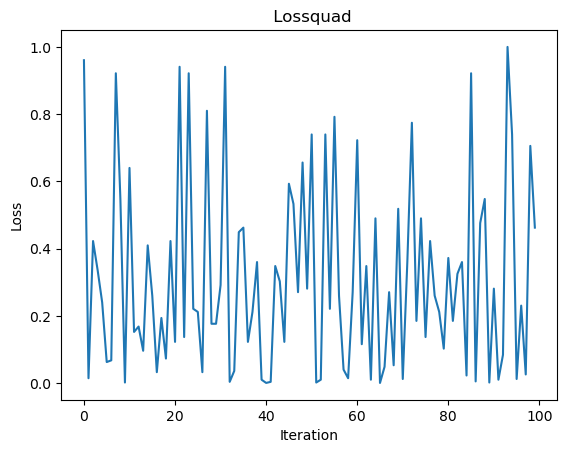

In [89]:
random_loss_values = [round(x, 2) for x in np.random.rand(100)]
plot_graph(random_loss_values, title=' Lossquad', xlabel='Iteration', ylabel='Loss', show=True)

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_animation(tensor_list, animation_name='animation.gif'):
    # Ensure tensor_list is not empty
    if not tensor_list:
        raise ValueError("The tensor list is empty.")
    
    # Get the dimensions of the tensors
    _, N, M = tensor_list[0].shape
    
    # Create a figure and axis for the animation
    fig, ax = plt.subplots()
    
    # Initialize the image with the first tensor
    im = ax.imshow(tensor_list[0].transpose(1, 2, 0), animated=True)
    
    # Update function for the animation
    def update(frame):
        im.set_array(frame.transpose(1, 2, 0))
        return im,
    
    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=tensor_list, blit=True)
    
    # Save the animation as a GIF file
    save_path = this_file_path.parent / 'Results' / animation_name
    ani.save(save_path, writer='pillow')
    
    plt.close(fig)
    print(f"Animation saved as {animation_name}")

# Example usage:
# Create a list of random tensors with dimensions [3, 100, 100]
tensor_list = [np.random.rand(3, 100, 100) for _ in range(10)]

# Create and save the animation
create_animation(tensor_list)


Animation saved as animation.gif


In [60]:
a = torch.Tensor(np.arange(0, 10 , 1))
b = torch.Tensor(np.arange(10, 20 , 1))
c = torch.stack([a, b], 1)
d = torch.cat([a, b], 0)
c.shape, c, d.shape, d

(torch.Size([10, 2]),
 tensor([[ 0., 10.],
         [ 1., 11.],
         [ 2., 12.],
         [ 3., 13.],
         [ 4., 14.],
         [ 5., 15.],
         [ 6., 16.],
         [ 7., 17.],
         [ 8., 18.],
         [ 9., 19.]]),
 torch.Size([20]),
 tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
         14., 15., 16., 17., 18., 19.]))

In [61]:
a, b , c = 0 , 2 , 1
a != b != c

True

In [62]:
# Create a train model funciton for a specified image couple
def train_model (model : MINE,
                homography_net : HomographyNet,
                optimizer : optim.Optimizer,
                fixed_pyramid : tuple[np.ndarray],
                moving_pyramid : tuple[np.ndarray],
                loss :nn.Module,
                n_epochs : int = 1,
                n_iterations : int = 50,
                device : str = None , # or 'cuda' or 'cpu'
                 ) -> None :
    '''
    the way to train a model through the parameter optimization of the homography net

    Parameters:
    -----------
        model (MINE): the net to calculate the mutual information parameter for optimize the model

        homography_net (HomographyNet): the net to calculate the homography matrix for the image couple
        
        optimizer (optim.Optimizer): the algorithm step to optimize the parameters of the homography net
        
        fixed_pyramid (tuple[np.ndarray]): the pyramid of the fixed image
        
        moving_pyramid (tuple[np.ndarray]): the pyramid of the moving image
        
        loss (nn.Module): the loss function to calculate the loss between the two images
        
        n_epochs (int): the number of epochs to train the model
        
        n_iterations (int): the number of iterations to train the model
        
        device (str): the device to use for the training

    '''
    pass

In [63]:
# per il training usa due diverse loss, la prima fa tutto all'interno del modello... l'altra fa in modo di avere un modello che trasforma l'immagine e successivamente calcola la loss tramite la mine net

In [64]:
# Create a funciton to save the image in a gif animation file to visualize the registration process

